In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid", font="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

# 데이터 경로 (ML_base_model과 동일)
BASE_DIR = Path().resolve().parent / "data"
train_path = BASE_DIR / "월세_train(24.01~25.08).csv"
test_path  = BASE_DIR / "월세_test(25.09~25.10).csv"

train = pd.read_csv(train_path, encoding="utf-8-sig")
test  = pd.read_csv(test_path,  encoding="utf-8-sig")

print(train.shape, test.shape)

# 타깃: 환산보증금_평당가
TARGET = "환산보증금_평당가"
TARGET_LOG = "log_" + TARGET

df_train = train.copy()
df_test  = test.copy()

for df in [df_train, df_test]:
    df["적용이자율"] = (df["기준금리"] + 2.0) / 100.0
    df.loc[df["적용이자율"] <= 0, "적용이자율"] = np.nan

    df["환산보증금(만원)"] = (df["보증금(만원)"] + df["임대료(만원)"] * 12) / df["적용이자율"]
    df["전용평수"] = df["임대면적"] / 3.3

    df[TARGET] = df["환산보증금(만원)"] / df["전용평수"]
    df[TARGET_LOG] = np.log1p(df[TARGET])

    df["연월_dt"] = pd.to_datetime(df["연월"] + "-01")

df_train[[TARGET, "연월", "연월_dt"]].head()


(618550, 17) (74617, 17)


,환산보증금_평당가,연월,연월_dt
0,18239.074550,2024-12,2024-12-01
1,32616.000000,2024-10,2024-10-01
2,4896.000000,2024-10,2024-10-01
3,4041.984733,2024-09,2024-09-01
4,2301.283221,2024-11,2024-11-01


In [2]:
! pip install ta -q

In [ ]:
from ta.volatility import BollingerBands

# 연월 기준으로 정렬
df_bb = df_train.sort_values("연월_dt").reset_index(drop=True)

# close 시계열 = 타깃
close = df_bb[TARGET]

# ta Bollinger Band (20일, 2σ 기본)
bb = BollingerBands(close=s, window=5, window_dev=1.5)  # 더 긴 기간, 더 얇은 밴드

df_bb["bb_mavg"] = bb.bollinger_mavg()
df_bb["bb_high"] = bb.bollinger_hband()
df_bb["bb_low"]  = bb.bollinger_lband()

# NaN이 아닌 구간만 확인
df_bb[["환산보증금_평당가", "bb_mavg", "bb_high", "bb_low"]].dropna().head()

,환산보증금_평당가,bb_mavg,bb_high,bb_low
9,26568.561873,8347.046984,25008.852381,-8314.758413
10,28646.802497,10947.783793,31006.740005,-9111.172418
11,40205.850488,14613.702175,40480.844784,-11253.440434
12,2623.834197,14616.601528,40478.360827,-11245.157770
13,18734.335350,16141.118302,40976.342621,-8694.106018


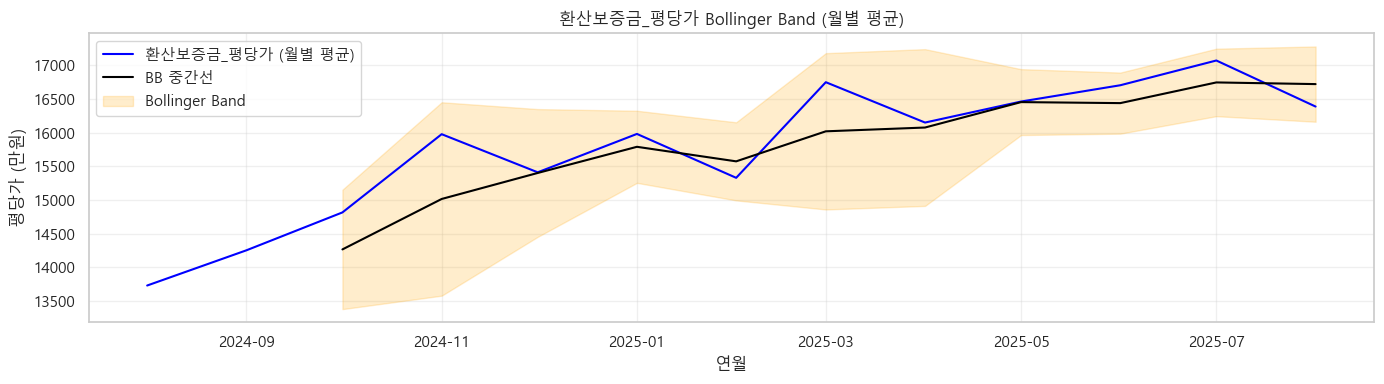

In [7]:
from ta.volatility import BollingerBands

# 1) 월별 평균 평당가 시계열 만들기
s = (
    df_train
    .groupby("연월_dt")[TARGET]   # TARGET = "환산보증금_평당가"
    .mean()
    .sort_index()
)

# 2) Bollinger Band 계산 (월별 데이터라 window는 3~6 정도가 적당)
bb = BollingerBands(close=s, window=3, window_dev=2)

df_bb = pd.DataFrame({
    "target": s,
    "bb_mavg": bb.bollinger_mavg(),
    "bb_high": bb.bollinger_hband(),
    "bb_low": bb.bollinger_lband(),
})

# 3) 시각화
plt.figure(figsize=(14, 4))
plt.plot(df_bb.index, df_bb["target"], label="환산보증금_평당가 (월별 평균)", color="blue")
plt.plot(df_bb.index, df_bb["bb_mavg"], label="BB 중간선", color="black")
plt.fill_between(df_bb.index, df_bb["bb_low"], df_bb["bb_high"],
                 color="orange", alpha=0.2, label="Bollinger Band")

plt.xlabel("연월")
plt.ylabel("평당가 (만원)")
plt.title("환산보증금_평당가 Bollinger Band (월별 평균)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
